Linearity test for N-path Rx

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import importlib
import utilities
importlib.reload(utilities)

from utilities import rc_lpf, npath_filter, plot_psd, rand_qpsk

Test for linearity using superposition

In [2]:
# PARAMETERS
f_s = 1e7           # Sampling rate
f_rf = 1e6          # RF carrier
f_lo = 1e6          # LO frequency
N = 4               # Number of paths
bw = 1e8            # LPF bandwidth
G = 1               # Baseband amplifier gain
Nfft = 4096         # FFT size
Nrep = 10           # Number of repetitions

# SUBPARAMETERS
R = 1
C = 1/(2*np.pi*R*bw)

# SUPERPOSITION PARAMETERS
alpha = 0.7
beta = 0.3

# COMPLEX BASEBAND INPUT 1
X1 = rand_qpsk(Nfft)
xtd1 = np.fft.ifft(X1)
xtd1_rep = np.tile(xtd1, Nrep)

# COMPLEX BASEBAND INPUT 2
X2 = rand_qpsk(Nfft)
xtd2 = np.fft.ifft(X2)
xtd2_rep = np.tile(xtd2, Nrep)

# UP-CONVERSION
t = np.arange(len(xtd1_rep)) / f_s
x_rf1 = np.real(xtd1_rep * np.exp(1j * 2*np.pi*f_rf*t))
x_rf2 = np.real(xtd2_rep * np.exp(1j * 2*np.pi*f_rf*t))

# N-PATH FILTER
y_paths1 = npath_filter(x_rf1, N, R, C, f_s, f_lo, return_paths=True)
y_paths2 = npath_filter(x_rf2, N, R, C, f_s, f_lo, return_paths=True)

# COMBINE PATHS
I1 = y_paths1[0, :] - y_paths1[2, :]
Q1 = y_paths1[1, :] - y_paths1[3, :]
y_out1 = I1 + 1j*Q1

I2 = y_paths2[0, :] - y_paths2[2, :]
Q2 = y_paths2[1, :] - y_paths2[3, :]
y_out2 = I2 + 1j*Q2

# BASEBAND AMPLIFIER + LPF
y_out1 = rc_lpf(G * y_out1, R=R, C=C, f_s=f_s, y_init=0)
y_out2 = rc_lpf(G * y_out2, R=R, C=C, f_s=f_s, y_init=0)

# SUPERPOSITION
x_rf_sup = alpha * x_rf1 + beta * x_rf2
y_paths_sup = npath_filter(x_rf_sup, N, R, C, f_s, f_lo, return_paths=True)
Isup = y_paths_sup[0, :] - y_paths_sup[2, :]
Qsup = y_paths_sup[1, :] - y_paths_sup[3, :]
y_out_sup = Isup + 1j*Qsup
y_out_sup = rc_lpf(G * y_out_sup, R=R, C=C, f_s=f_s, y_init=0)

# NON-LINEARITY METRIC
nonlinearity = np.linalg.norm(y_out_sup - (alpha * y_out1 + beta * y_out2))
print("nonlinearity metric:", nonlinearity)

nonlinearity metric: 2.7344632117972497e-16


Testing using system transfer function (fails since the system is time variant)

nonlinearity metric: 1.4092485890723998


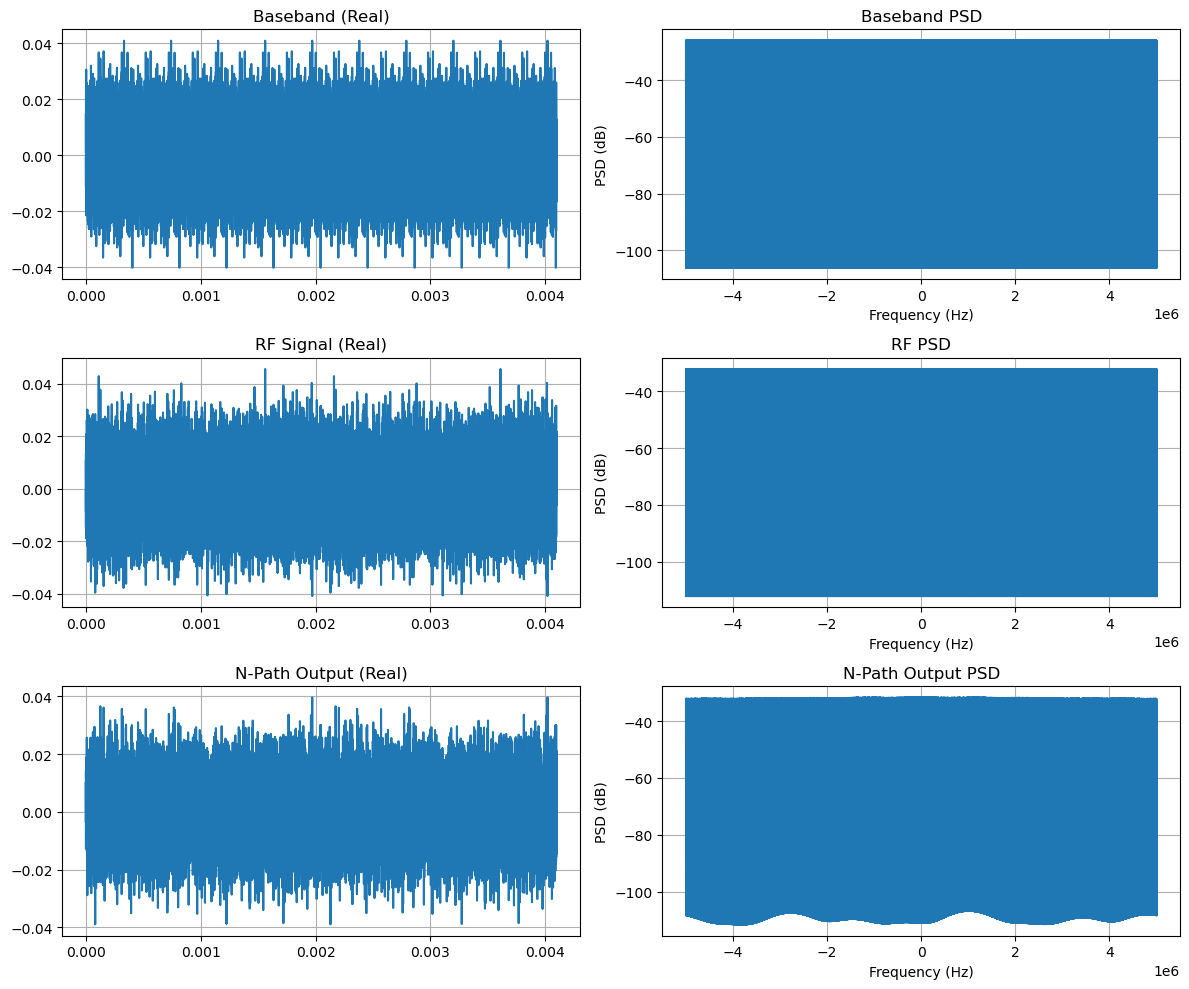

In [3]:
# PARAMETERS
f_s = 1e7           # Sampling rate
f_rf = 1e6          # RF carrier
f_lo = 1e6          # LO frequency
N = 4               # Number of paths
bw = 1e8          # LPF bandwidth
G = 1              # Baseband amplifier gain
Nfft = 4096         # FFT size
Nrep = 10           # Number of repetitions

# SUBPARAMETERS
R = 1
C = 1/(2*np.pi*R*bw)

# COMPLEX BASEBAND INPUT
X = rand_qpsk(Nfft)
xtd = np.fft.ifft(X)
xtd_rep = np.tile(xtd, Nrep)

# UP-CONVERSION
t = np.arange(len(xtd_rep)) / f_s
x_rf = np.real(xtd_rep * np.exp(1j * 2*np.pi*f_rf*t))

# N-PATH FILTER
y_paths = npath_filter(x_rf, N, R, C, f_s, f_lo, return_paths=True)

# COMBINE PATHS
I = y_paths[0, :] - y_paths[2, :]
Q = y_paths[1, :] - y_paths[3, :]
y_out = I + 1j*Q

# BASEBAND AMPLIFIER + LPF
y_out = rc_lpf(G * y_out, R=R, C=C, f_s=f_s, y_init=0)

# SYSTEM TRANSFER FUNCTION
Y = np.fft.fft(y_out[(Nrep-2)*Nfft:(Nrep-1)*Nfft])
H = Y / X

# NON-LINEARITY METRIC
X2 = rand_qpsk(Nfft)
xtd2 = np.fft.ifft(X2)
xtd2_rep = np.tile(xtd2, Nrep)

t2 = np.arange(len(xtd2_rep)) / f_s
x_rf2 = np.real(xtd2_rep * np.exp(1j * 2*np.pi*f_rf*t2))

y_paths2 = npath_filter(x_rf2, N, R, C, f_s, f_lo, return_paths=True)
I2 = y_paths2[0, :] - y_paths2[2, :]
Q2 = y_paths2[1, :] - y_paths2[3, :]
y_out2 = I2 + 1j*Q2
y_out2 = rc_lpf(G * y_out2, R=R, C=C, f_s=f_s, y_init=0)

Y2 = np.fft.fft(y_out2[(Nrep-2)*Nfft:(Nrep-1)*Nfft])
Y2_hat = H * X2

nonlinearity = np.linalg.norm(Y2 - Y2_hat) / np.linalg.norm(Y2)
print("nonlinearity metric:", nonlinearity)

# PSD PLOTS
plt.figure(figsize=(12, 10))
plt.subplot(3,2,1)
plt.plot(t, np.real(xtd_rep))
plt.title("Baseband (Real)")
plt.grid(True)

plt.subplot(3,2,2)
plot_psd(xtd_rep, f_s, "Baseband PSD")

plt.subplot(3,2,3)
plt.plot(t, np.real(x_rf))
plt.title("RF Signal (Real)")
plt.grid(True)

plt.subplot(3,2,4)
plot_psd(x_rf, f_s, "RF PSD")

plt.subplot(3,2,5)
plt.plot(t, np.real(y_out))
plt.title("N-Path Output (Real)")
plt.grid(True)

plt.subplot(3,2,6)
plot_psd(y_out, f_s, "N-Path Output PSD")

plt.tight_layout()
plt.show()